# Model Evaluation

This notebook focuses on evaluating the performance of a trained geo-spatial model. It loads the saved model and test data, computes relevant performance metrics, and visualizes the results to assess model accuracy and generalization. Amongst other metrics, it calculates overall accuracy, balanced accuracy, per-class performance and plots confusion matrices.

Expected input format for the data: .npz file in the directory `EVAL_ROOT` with the name `evaluation_outputs.npz`. The file should contain true and predicted classes on the test set, as well as the class names. This format fits with the file saved at the end of the `3_training_pipeline.ipynb` notebook. 

In [1]:
# TODO: Remove unused libraries

In [2]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

import pytorch_lightning as pl
from pytorch_lightning import Trainer

from sklearn.metrics import (
    confusion_matrix, classification_report, 
    balanced_accuracy_score, f1_score,
    precision_score, recall_score
)

print("✓ Imports successful")

✓ Imports successful


In [3]:
%matplotlib inline

In [4]:
import os
SCRATCH = os.getenv("SCRATCH")
EVAL_ROOT = Path(f"{SCRATCH}/team1/data/evaluation")

### Import Evaluation Data (test predictions)

In [5]:
from pathlib import Path
import numpy as np

EVAL_PATH = Path(EVAL_ROOT) / "evaluation_outputs.npz"

data = np.load(EVAL_PATH, allow_pickle=True)

y_true = data["y_true"]
y_pred = data["y_pred"]
class_names = data["class_names"].tolist()
class_names_with_idx = [f"{i}: {name}" for i, name in enumerate(class_names)]

n_classes = len(class_names)

print(f"Test set: {len(y_true)} samples, {n_classes} classes")
print(f"Ground truth distribution: {np.bincount(y_true, minlength=n_classes)}")
print(f"Prediction distribution:  {np.bincount(y_pred, minlength=n_classes)}")
print(class_names)

Test set: 9997 samples, 8 classes
Ground truth distribution: [ 166 6860  193  494  768  275  783  458]
Prediction distribution:  [ 256    0  122    5 9486    0    0  128]
['agriculture_with_natural_vegetation', 'coniferous_forest', 'discontinuous_urban_fabric', 'mixed_forest', 'non_irrigated_arable_land', 'peat_bogs', 'transitional_woodland_shrub', 'water_bodies']


### Evaluation Functions

- Overall Accuracy: % of all correct predictions
- Balanced Accuracy: Mean recall per class (immune to imbalance)
- Macro-F1: Mean F1 per class

In [6]:
def _confusion_matrix(y_true, y_pred):
    """Build confusion matrix handling arbitrary class labels."""
    labels = np.unique(np.concatenate([y_true, y_pred]))
    label_to_idx = {int(lbl): i for i, lbl in enumerate(labels)}
    cm = np.zeros((len(labels), len(labels)), dtype=np.int64)
    for t, p in zip(y_true, y_pred):
        cm[label_to_idx[int(t)], label_to_idx[int(p)]] += 1
    return labels, cm

In [7]:
def _imbalanced_metrics_from_cm(cm):
    """Compute balanced accuracy, macro-F1, and per-class metrics from confusion matrix."""
    tp = np.diag(cm).astype(np.float64)
    support = cm.sum(axis=1).astype(np.float64)
    pred_count = cm.sum(axis=0).astype(np.float64)

    recall = np.divide(tp, support, out=np.zeros_like(tp), where=support > 0)
    precision = np.divide(tp, pred_count, out=np.zeros_like(tp), where=pred_count > 0)
    f1 = np.divide(
        2 * precision * recall,
        precision + recall,
        out=np.zeros_like(tp),
        where=(precision + recall) > 0,
    )

    balanced_acc = recall.mean()
    macro_f1 = f1.mean()
    overall_acc = tp.sum() / cm.sum() if cm.sum() > 0 else 0.0
    return overall_acc, balanced_acc, macro_f1, recall, precision, f1

### Compute Overall Metrics

In [8]:
labels, cm = _confusion_matrix(y_true, y_pred)
overall_acc, balanced_acc, macro_f1, recall, precision, f1 = _imbalanced_metrics_from_cm(cm)

print("Overall Metrics:")
print(f"  Overall Accuracy:  {overall_acc:.4f}")
print(f"  Balanced Accuracy: {balanced_acc:.4f}")
print(f"  Macro-F1:          {macro_f1:.4f}")
print(f"  Gap (Acc - Bal):   {overall_acc - balanced_acc:.4f}")

# Majority baseline
vals, cnts = np.unique(y_true, return_counts=True)
majority_baseline = cnts.max() / len(y_true)
print(f"\nMajority baseline:  {majority_baseline:.4f}")
print(f"Model improvement:  {balanced_acc - majority_baseline:.4f}")

Overall Metrics:
  Overall Accuracy:  0.0872
  Balanced Accuracy: 0.1595
  Macro-F1:          0.0696
  Gap (Acc - Bal):   -0.0723

Majority baseline:  0.6862
Model improvement:  -0.5267


### Per-Class Metrics

In [9]:
report = classification_report(
    y_true, y_pred,
    target_names=class_names_with_idx,
    digits=4,
    zero_division=0
)

print(report)

                                        precision    recall  f1-score   support

0: agriculture_with_natural_vegetation     0.0391    0.0602    0.0474       166
                  1: coniferous_forest     0.0000    0.0000    0.0000      6860
         2: discontinuous_urban_fabric     0.0000    0.0000    0.0000       193
                       3: mixed_forest     0.0000    0.0000    0.0000       494
          4: non_irrigated_arable_land     0.0797    0.9844    0.1475       768
                          5: peat_bogs     0.0000    0.0000    0.0000       275
        6: transitional_woodland_shrub     0.0000    0.0000    0.0000       783
                       7: water_bodies     0.8281    0.2314    0.3618       458

                              accuracy                         0.0872      9997
                             macro avg     0.1184    0.1595    0.0696      9997
                          weighted avg     0.0447    0.0872    0.0287      9997



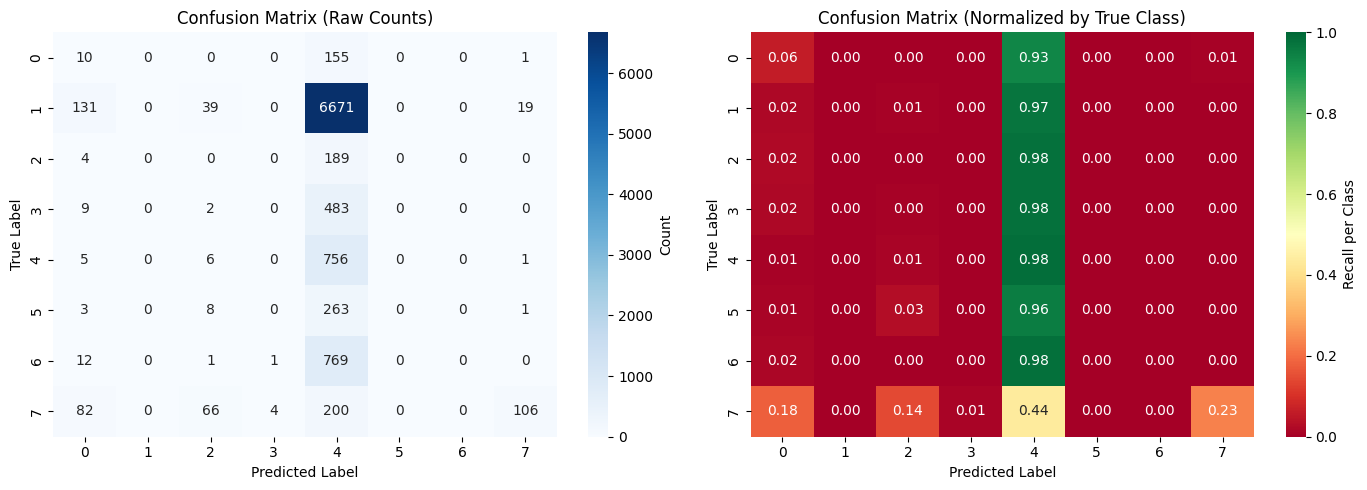

Diagonal = correct predictions per class
Dark values in confusion matrix indicate accurate predictions


In [10]:
cm = confusion_matrix(y_true, y_pred, labels=range(n_classes))
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar_kws={'label': 'Count'},
            xticklabels=range(n_classes), yticklabels=range(n_classes),
            ax=axes[0])
axes[0].set_title('Confusion Matrix (Raw Counts)')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='RdYlGn', vmin=0, vmax=1,
            cbar_kws={'label': 'Recall per Class'},
            xticklabels=range(n_classes), yticklabels=range(n_classes),
            ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalized by True Class)')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

print("Diagonal = correct predictions per class")
print("Dark values in confusion matrix indicate accurate predictions")

### Class Distribution Analysis

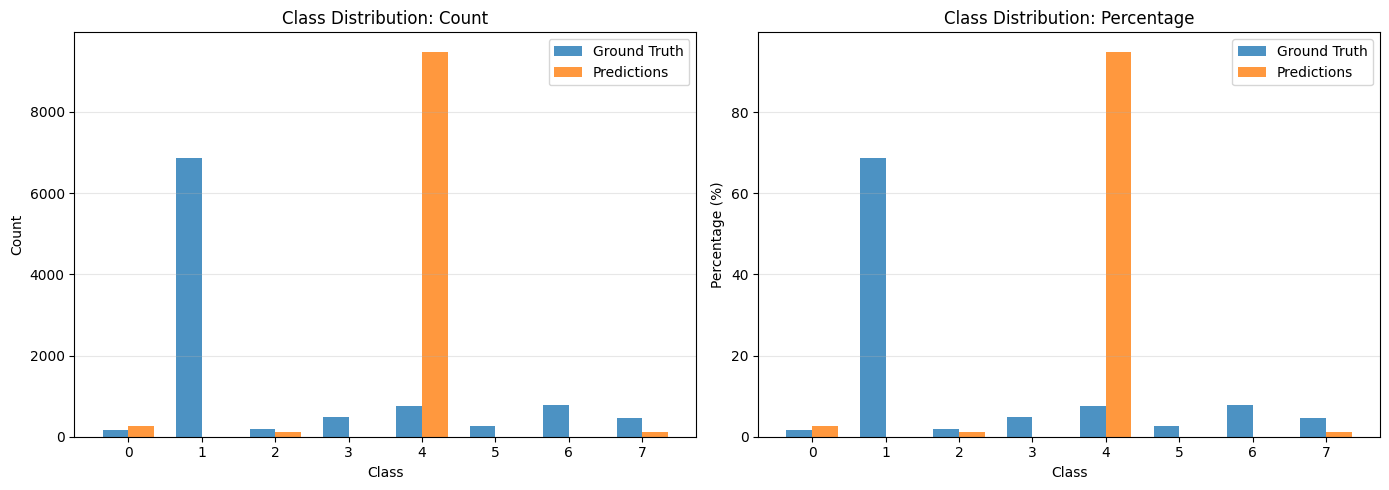

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

true_dist = pd.Series(y_true).value_counts().sort_index()
pred_dist = pd.Series(y_pred).value_counts().sort_index()

for i in range(n_classes):
    if i not in true_dist.index:
        true_dist[i] = 0
    if i not in pred_dist.index:
        pred_dist[i] = 0

true_dist = true_dist.sort_index()
pred_dist = pred_dist.sort_index()

# Count plot
x_pos = np.arange(n_classes)
width = 0.35
axes[0].bar(x_pos - width/2, true_dist.values, width, label='Ground Truth', alpha=0.8)
axes[0].bar(x_pos + width/2, pred_dist.values, width, label='Predictions', alpha=0.8)
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
axes[0].set_title('Class Distribution: Count')
axes[0].set_xticks(x_pos)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Percentage plot
true_pct = 100 * true_dist / true_dist.sum()
pred_pct = 100 * pred_dist / pred_dist.sum()

axes[1].bar(x_pos - width/2, true_pct.values, width, label='Ground Truth', alpha=0.8)
axes[1].bar(x_pos + width/2, pred_pct.values, width, label='Predictions', alpha=0.8)
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_title('Class Distribution: Percentage')
axes[1].set_xticks(x_pos)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
# Print summary of class distributions for true and predicted classes
df = pd.DataFrame({
    "Class": class_names_with_idx,
    "True %": true_pct.values,
    "Pred %": pred_pct.values,
})

df["Difference"] = df["Pred %"] - df["True %"]

# Format nicely
df["True %"] = df["True %"].map("{:.1f}%".format)
df["Pred %"] = df["Pred %"].map("{:.1f}%".format)
df["Difference"] = df["Difference"].map("{:+.1f}%".format)

print(df.to_string(index=False))

                                 Class True % Pred % Difference
0: agriculture_with_natural_vegetation   1.7%   2.6%      +0.9%
                  1: coniferous_forest  68.6%   0.0%     -68.6%
         2: discontinuous_urban_fabric   1.9%   1.2%      -0.7%
                       3: mixed_forest   4.9%   0.1%      -4.9%
          4: non_irrigated_arable_land   7.7%  94.9%     +87.2%
                          5: peat_bogs   2.8%   0.0%      -2.8%
        6: transitional_woodland_shrub   7.8%   0.0%      -7.8%
                       7: water_bodies   4.6%   1.3%      -3.3%
